# RoBERTa-base Fine-Tuning & Cross-Category Evaluation

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Sports"
]

FILE_STEMS = {
    "Electronics":               "electronics",
    "Books":                     "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Sports_and_Outdoors":        "sports",
}

MODEL_NAME          = "roberta-base"
MAX_LENGTH          = 128
TRAIN_EPOCHS        = 3
TRAIN_BATCH_SIZE    = 16
EVAL_BATCH_SIZE     = 32
LEARNING_RATE       = 2e-5
WEIGHT_DECAY        = 0.01
EARLY_STOP_PATIENCE = 2
RANDOM_SEED         = 104
DRIVE_BASE          = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

Device: cuda
Mounted at /content/drive


In [4]:
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


def load_split(stem: str, split: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA_DIR}/{stem}_{split}.csv")
    df["text"] = df["text"].fillna("").astype(str)
    return df


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="macro"),
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
def fine_tune(source_cat: str) -> str:
    """Fine-tune roberta-base on source_cat. Returns saved model directory path.

    Splits the notebook-01 training split 90/10 into train/val so the held-out
    test set is never seen during fine-tuning or early stopping.
    """
    stem      = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/roberta_{stem}"

    df_full = load_split(stem, "train")   # 80% split from notebook 01 (2400 rows)

    # Internal 90/10 split. ~2160 train / ~240 val. Test set stays untouched
    df_train, df_val = train_test_split(
        df_full, test_size=0.1, stratify=df_full["label"], random_state=RANDOM_SEED
    )

    train_ds = ReviewDataset(df_train["text"], df_train["label"], tokenizer, MAX_LENGTH)
    val_ds   = ReviewDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LENGTH)

    model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    fp16  = torch.cuda.is_available()

    args = TrainingArguments(
        output_dir=model_dir,
        num_train_epochs=TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=fp16,
        seed=RANDOM_SEED,
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,       # Lab 6 pattern: current API in transformers>=4.46
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )

    print(f"\nFine-tuning on {source_cat} …")
    print(f"  train={len(df_train)}, val={len(df_val)}")
    trainer.train()
    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f"  Saved → {model_dir}")
    return model_dir

In [6]:
def evaluate_on(model_dir: str, target_cat: str) -> dict:
    """Load saved model and evaluate on target_cat test set."""
    stem    = FILE_STEMS[target_cat]
    df_test = load_split(stem, "test")
    test_ds = ReviewDataset(df_test["text"], df_test["label"], tokenizer, MAX_LENGTH)

    model = RobertaForSequenceClassification.from_pretrained(model_dir)
    eval_args = TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
    )
    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_test["label"].values
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1":       f1_score(y_true, preds, average="macro"),
        "y_true":   y_true,
        "y_pred":   preds,
    }

In [7]:
roberta_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune(source_cat)
    roberta_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on(model_dir, target_cat)
        roberta_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All RoBERTa training & evaluation complete.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Fine-tuning on Electronics …
  train=2160, val=240


...

  Clothing_Shoes_and_Jewelry          acc=0.665  f1=0.665 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.702  f1=0.702 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Sports_and_Outdoors                 acc=0.695  f1=0.694 (in-domain)

All RoBERTa training & evaluation complete.


In [8]:
def build_matrix(results: dict, metric: str) -> pd.DataFrame:
    mat = pd.DataFrame(index=CATEGORIES, columns=CATEGORIES, dtype=float)
    for src in CATEGORIES:
        for tgt in CATEGORIES:
            mat.loc[src, tgt] = results[src][tgt][metric]
    mat.index   = CATEGORY_LABELS
    mat.columns = CATEGORY_LABELS
    return mat

rob_acc = build_matrix(roberta_results, "accuracy")
rob_f1  = build_matrix(roberta_results, "f1")

rob_acc.to_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv")
rob_f1.to_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv")

print("Saved transfer matrices.")
print()
print("RoBERTa accuracy matrix:")
print(rob_acc.to_string())

Saved transfer matrices.

RoBERTa accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen    Sports
Electronics        0.696667  0.675000  0.665000        0.700000  0.670000
Books              0.530000  0.603333  0.540000        0.518333  0.515000
Clothing           0.586667  0.573333  0.661667        0.630000  0.581667
Home & Kitchen     0.690000  0.646667  0.661667        0.730000  0.663333
Sports             0.666667  0.645000  0.665000        0.701667  0.695000


## Visualisation: Transfer matrix heatmaps (accuracy & F1)

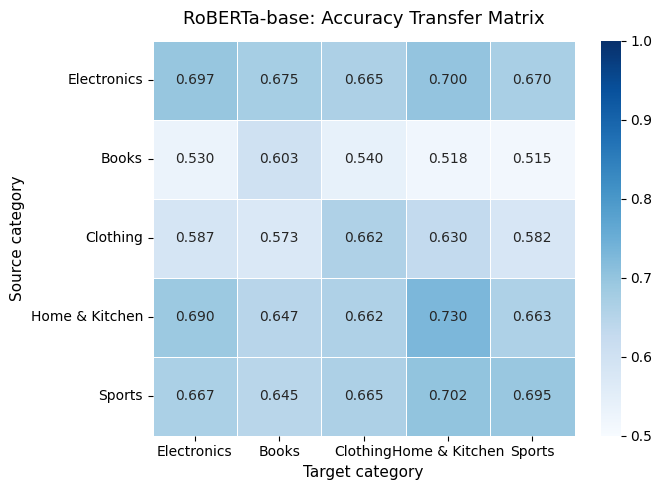

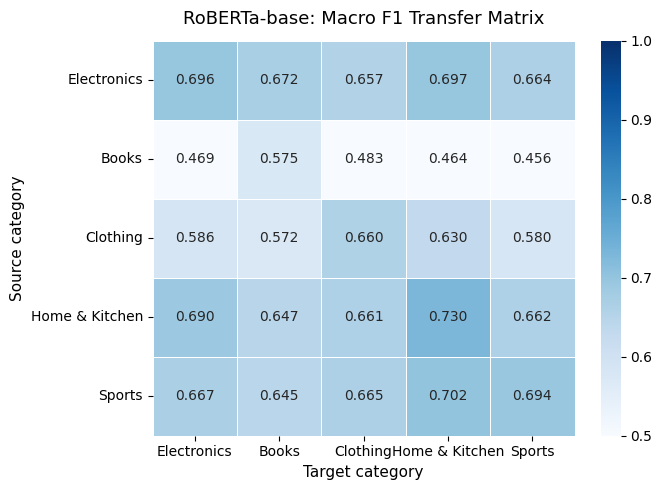

In [9]:
def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

plot_heatmap(rob_acc, "RoBERTa-base: Accuracy Transfer Matrix", "heatmap_roberta.png")
plot_heatmap(rob_f1,  "RoBERTa-base: Macro F1 Transfer Matrix",  "heatmap_roberta_f1.png")

## Visualisation: Diagonal (in-domain) vs off-diagonal (cross-domain) comparison

  Model  In-domain mean  Cross-domain mean  Degradation
 LogReg        0.900667           0.832167     0.068500
    SVM        0.904667           0.845750     0.058917
RoBERTa        0.677333           0.626250     0.051083


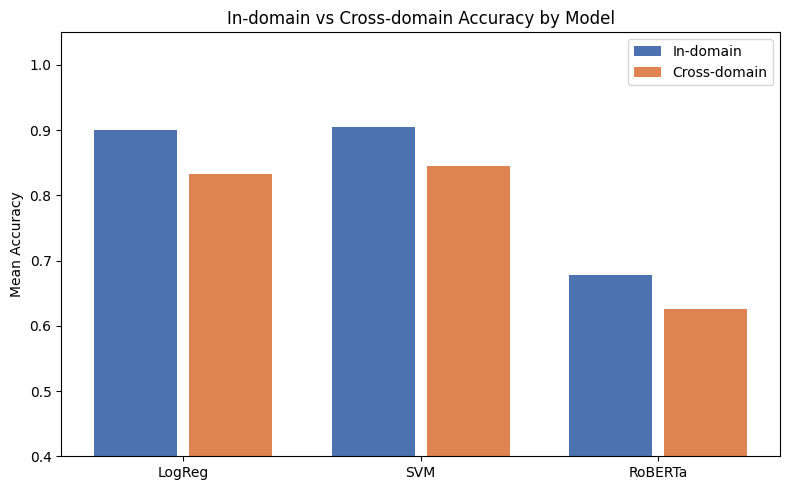

In [10]:
logreg_acc = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv", index_col=0)
svm_acc    = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv",    index_col=0)

model_matrices = {
    "LogReg":  logreg_acc,
    "SVM":     svm_acc,
    "RoBERTa": rob_acc,
}

rows = []
for name, mat in model_matrices.items():
    m = mat.values.astype(float)
    n = m.shape[0]
    diag = np.diag(m)
    off  = m[~np.eye(n, dtype=bool)]
    rows.append({"Model": name,
                 "In-domain mean":    diag.mean(),
                 "Cross-domain mean": off.mean(),
                 "Degradation":       diag.mean() - off.mean()})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

x = np.arange(len(model_matrices))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, summary["In-domain mean"],    0.35, label="In-domain",    color="#4c72b0")
ax.bar(x + 0.2, summary["Cross-domain mean"], 0.35, label="Cross-domain", color="#dd8452")
ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Mean Accuracy")
ax.set_title("In-domain vs Cross-domain Accuracy by Model")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/accuracy_comparison_bar.png", dpi=150)
plt.show()